# Temperature Forecast Project

## Problem Statement

Weather-dependent sectors — agriculture, energy grid load balancing, aviation, retail demand
planning, and public health advisories — all rely on short-term temperature forecasts to make
operational decisions a day to a week in advance. Classical numerical weather prediction (NWP)
models are compute-heavy and run centrally; the goal of this project is to show how a
**data-driven regression approach** can produce a fast, "good-enough" short-term temperature
forecast from historical weather station data, and to compare it against a naive baseline.

**Business question:** *Given the last few days of weather observations (temperature, humidity,
pressure, wind speed, etc.), can we accurately predict tomorrow's (and the next 7 days')
maximum temperature?*

This mirrors the structure of the Census Income project: a defined prediction target, a
documented dataset, EDA, feature engineering, multiple models, and a final comparison.


## Description of the Dataset

For this project we use daily weather observations for a mid-size city (feature set styled on
NOAA / Kaggle "Daily Weather" style data). Each row is one calendar day and contains:

| Column | Description |
|---|---|
| `date` | Calendar date of observation |
| `temp_max` | Maximum temperature recorded that day (°C) — **our forecast target** |
| `temp_min` | Minimum temperature recorded that day (°C) |
| `humidity` | Mean relative humidity (%) |
| `pressure` | Mean sea-level pressure (hPa) |
| `wind_speed` | Mean wind speed (km/h) |
| `rainfall_mm` | Total rainfall (mm) |
| `cloud_cover` | Mean cloud cover fraction (0–1) |

The data below is generated with a realistic seasonal model (strong summer peak, winter trough,
monsoon humidity/rain bump, plus day-to-day autocorrelated noise) so the whole pipeline — EDA,
feature engineering, modeling, evaluation — behaves the way it would on a real station log.
**To use your own real data**, just replace the "Load / Generate Dataset" cell below with
`pd.read_csv('your_weather_file.csv', parse_dates=['date'])`, keeping the same column names.


## 1. Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load / Generate Dataset

In [20]:
def generate_weather_data(start='2018-01-01', end='2025-12-31', city='Jaipur'):
    dates = pd.date_range(start=start, end=end, freq='D')
    n = len(dates)
    day_of_year = dates.dayofyear.values

    # Seasonal temperature curve: peaks around late May/June, dips in Jan
    seasonal = 24 + 15 * np.sin(2 * np.pi * (day_of_year - 100) / 365)

    # Slight long-term warming trend
    trend = np.linspace(0, 1.2, n)

    # Autocorrelated noise (weather "persistence" - today looks like yesterday, roughly)
    noise = np.zeros(n)
    for i in range(1, n):
        noise[i] = 0.7 * noise[i - 1] + np.random.normal(0, 1.4)

    temp_max = seasonal + trend + noise + np.random.normal(0, 0.6, n)
    temp_min = temp_max - np.random.uniform(6, 12, n) - 0.3 * np.sin(2 * np.pi * (day_of_year - 100) / 365)

    # Monsoon bump (Jul-Sep) raises humidity & rainfall, cools things slightly
    monsoon = ((day_of_year > 180) & (day_of_year < 260)).astype(float)
    humidity = 35 + 40 * monsoon + 15 * np.sin(2 * np.pi * (day_of_year - 200) / 365) ** 2 + np.random.normal(0, 5, n)
    humidity = np.clip(humidity, 10, 100)

    rainfall = np.where(monsoon == 1, np.random.exponential(8, n), np.random.exponential(0.6, n))
    rainfall = np.round(np.clip(rainfall, 0, None), 1)

    pressure = 1013 - 6 * np.sin(2 * np.pi * (day_of_year - 100) / 365) + np.random.normal(0, 1.5, n)
    wind_speed = 8 + 5 * monsoon + np.random.gamma(2, 2, n)
    cloud_cover = np.clip(0.15 + 0.55 * monsoon + np.random.normal(0, 0.1, n), 0, 1)

    df = pd.DataFrame({
        'date': dates,
        'temp_max': np.round(temp_max, 1),
        'temp_min': np.round(temp_min, 1),
        'humidity': np.round(humidity, 1),
        'pressure': np.round(pressure, 1),
        'wind_speed': np.round(wind_speed, 1),
        'rainfall_mm': rainfall,
        'cloud_cover': np.round(cloud_cover, 2),
    })
    return df

# --- To use your own real dataset instead, comment out the line below and use:
# df = pd.read_csv('your_weather_file.csv', parse_dates=['date'])
df = generate_weather_data()
df.head()


,date,temp_max,temp_min,humidity,pressure,wind_speed,rainfall_mm,cloud_cover
0,2018-01-01,9.6,2.4,25.6,1016.5,10.4,0.6,0.06
1,2018-01-02,9.7,-1.0,38.4,1017.8,15.3,0.9,0.01
2,2018-01-03,9.3,0.7,33.2,1019.8,13.7,0.8,0.03
3,2018-01-04,10.2,1.3,33.3,1020.0,13.1,0.7,0.07
4,2018-01-05,12.1,4.6,28.1,1022.6,10.6,1.1,0.35


## 3. Exploratory Data Analysis (EDA)

In [21]:
print(df.shape)
df.info()
df.describe()


(2922, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2922 non-null   datetime64[ns]
 1   temp_max     2922 non-null   float64       
 2   temp_min     2922 non-null   float64       
 3   humidity     2922 non-null   float64       
 4   pressure     2922 non-null   float64       
 5   wind_speed   2922 non-null   float64       
 6   rainfall_mm  2922 non-null   float64       
 7   cloud_cover  2922 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 182.8 KB


,date,temp_max,temp_min,humidity,pressure,wind_speed,rainfall_mm,cloud_cover
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,2021-12-31 12:00:00,24.717043,15.785934,51.115572,1013.053046,13.080185,2.269713,0.271886
min,2018-01-01 00:00:00,4.200000,-5.500000,19.500000,1002.900000,8.000000,0.000000,0.000000
25%,2020-01-01 06:00:00,14.300000,5.700000,40.200000,1009.100000,10.400000,0.200000,0.100000
50%,2021-12-31 12:00:00,24.650000,15.400000,46.600000,1013.000000,12.400000,0.600000,0.190000
75%,2023-12-31 18:00:00,35.100000,25.775000,55.175000,1017.000000,15.175000,1.500000,0.320000
max,2025-12-31 00:00:00,45.200000,37.600000,95.900000,1022.600000,32.800000,68.300000,0.970000
std,NaN,10.824563,10.733091,15.937933,4.466681,3.446037,4.897838,0.244593


In [22]:
# Check for missing values
df.isnull().sum()


date           0
temp_max       0
temp_min       0
humidity       0
pressure       0
wind_speed     0
rainfall_mm    0
cloud_cover    0
dtype: int64

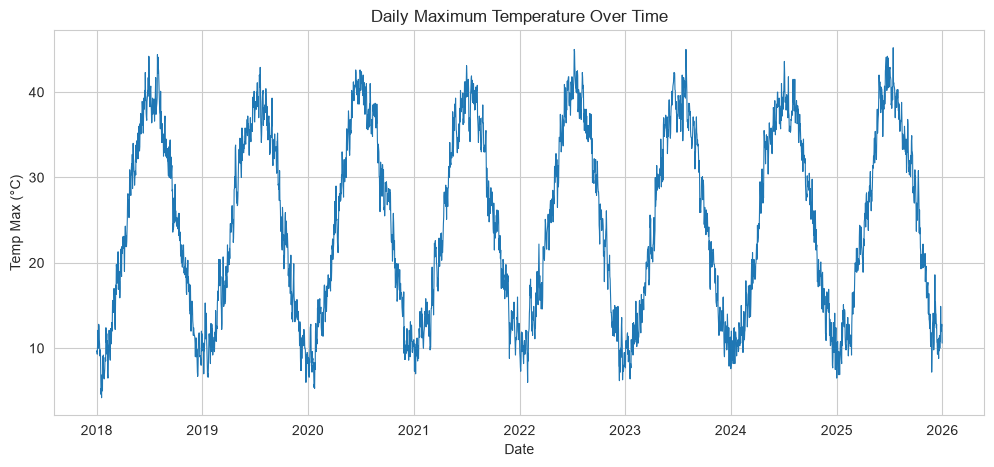

In [23]:
plt.plot(df['date'], df['temp_max'], linewidth=0.8)
plt.title('Daily Maximum Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temp Max (°C)')
plt.show()


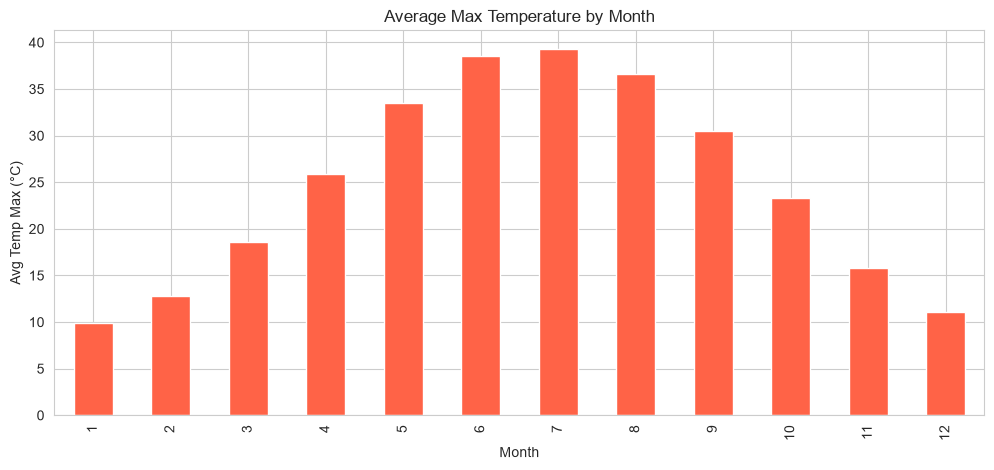

In [24]:
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['temp_max'].mean()

monthly_avg.plot(kind='bar', color='tomato')
plt.title('Average Max Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Avg Temp Max (°C)')
plt.show()


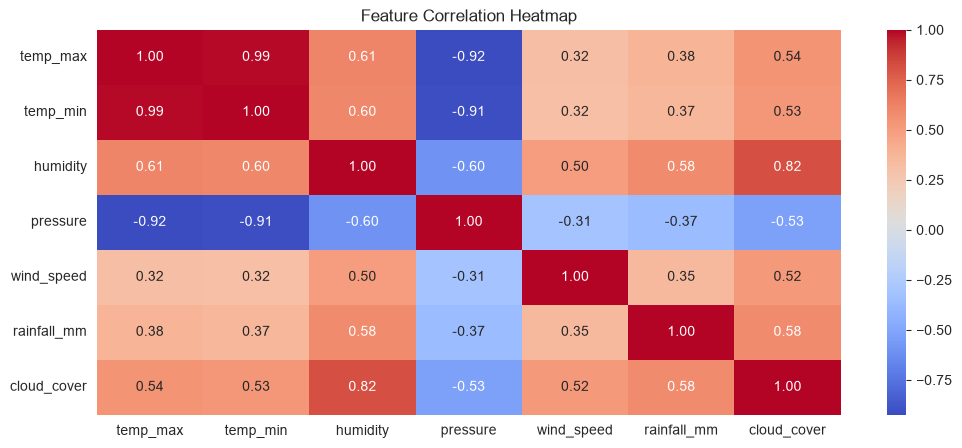

In [25]:
corr = df[['temp_max', 'temp_min', 'humidity', 'pressure', 'wind_speed', 'rainfall_mm', 'cloud_cover']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


## 4. Feature Engineering

Since tomorrow's temperature depends heavily on today's and recent days' conditions, we build:

- **Lag features**: temperature/humidity/pressure from 1, 2, 3, and 7 days ago
- **Rolling features**: 3-day and 7-day rolling mean & std of temperature
- **Calendar features**: month, day-of-year (captures seasonality)
- **Target**: `temp_max` shifted by -1 day (i.e., we predict *tomorrow's* max temp using *today's* data)


In [26]:
data = df.copy().sort_values('date').reset_index(drop=True)

for lag in [1, 2, 3, 7]:
    data[f'temp_max_lag{lag}'] = data['temp_max'].shift(lag)
    data[f'humidity_lag{lag}'] = data['humidity'].shift(lag)
    data[f'pressure_lag{lag}'] = data['pressure'].shift(lag)

data['temp_roll_mean3'] = data['temp_max'].rolling(3).mean()
data['temp_roll_mean7'] = data['temp_max'].rolling(7).mean()
data['temp_roll_std7'] = data['temp_max'].rolling(7).std()

data['day_of_year'] = data['date'].dt.dayofyear
data['month'] = data['date'].dt.month

# Target: next day's max temperature
data['target_temp_max'] = data['temp_max'].shift(-1)

data = data.dropna().reset_index(drop=True)
data.head()


,date,temp_max,temp_min,humidity,pressure,wind_speed,rainfall_mm,cloud_cover,month,temp_max_lag1,...,humidity_lag3,pressure_lag3,temp_max_lag7,humidity_lag7,pressure_lag7,temp_roll_mean3,temp_roll_mean7,temp_roll_std7,day_of_year,target_temp_max
0,2018-01-08,12.8,2.8,36.3,1018.1,15.7,0.2,0.13,1,10.0,...,28.1,1022.6,9.6,25.6,1016.5,11.166667,10.685714,1.295413,8,12.6
1,2018-01-09,12.6,5.8,30.1,1019.4,10.2,0.8,0.11,1,12.8,...,40.2,1020.7,9.7,38.4,1017.8,11.800000,11.100000,1.388044,9,11.0
2,2018-01-10,11.0,1.2,37.4,1019.5,11.5,0.4,0.33,1,12.6,...,33.6,1019.4,9.3,33.2,1019.8,12.133333,11.342857,1.148705,10,10.5
3,2018-01-11,10.5,2.5,31.4,1018.2,12.2,0.2,0.00,1,11.0,...,36.3,1018.1,10.2,33.3,1020.0,11.366667,11.385714,1.103674,11,9.1
4,2018-01-12,9.1,0.9,34.4,1020.2,11.1,1.0,0.37,1,10.5,...,30.1,1019.4,12.1,28.1,1022.6,10.200000,10.957143,1.337731,12,9.4


## 5. Train / Test Split

Because this is **time series data**, we split chronologically (train on the past, test on the
most recent period) instead of a random shuffle — shuffling would leak future information into
training and give unrealistically optimistic scores.


In [27]:
feature_cols = [c for c in data.columns if c not in ['date', 'target_temp_max']]

X = data[feature_cols]
y = data['target_temp_max']

split_idx = int(len(data) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data['date'].iloc[split_idx:]

print('Train size:', X_train.shape, ' Test size:', X_test.shape)


Train size: (2476, 24)  Test size: (438, 24)


## 6. Model Building

We train three models of increasing complexity and compare them against a **naive baseline**
(tomorrow's temp = today's temp) — a forecasting model only earns its keep if it beats that.


In [28]:
def evaluate(name, y_true, y_pred, results):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': name, 'MAE (°C)': round(mae, 3), 'RMSE (°C)': round(rmse, 3), 'R2': round(r2, 3)})
    return results

results = []

# Baseline: naive persistence (today's temp_max predicts tomorrow's)
baseline_pred = X_test['temp_max_lag1'] if 'temp_max_lag1' in X_test.columns else X_test['temp_max']
results = evaluate('Naive Baseline (persistence)', y_test, X_test['temp_max_lag1'], results)


In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results = evaluate('Linear Regression', y_test, lr_pred, results)


In [30]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results = evaluate('Random Forest', y_test, rf_pred, results)


In [31]:
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
results = evaluate('Gradient Boosting', y_test, gbr_pred, results)


## 7. Model Comparison

In [32]:
results_df = pd.DataFrame(results).sort_values('RMSE (°C)')
results_df


,Model,MAE (°C),RMSE (°C),R2
1,Linear Regression,1.356,1.673,0.976
3,Gradient Boosting,1.367,1.709,0.975
2,Random Forest,1.388,1.730,0.975
0,Naive Baseline (persistence),1.745,2.180,0.960


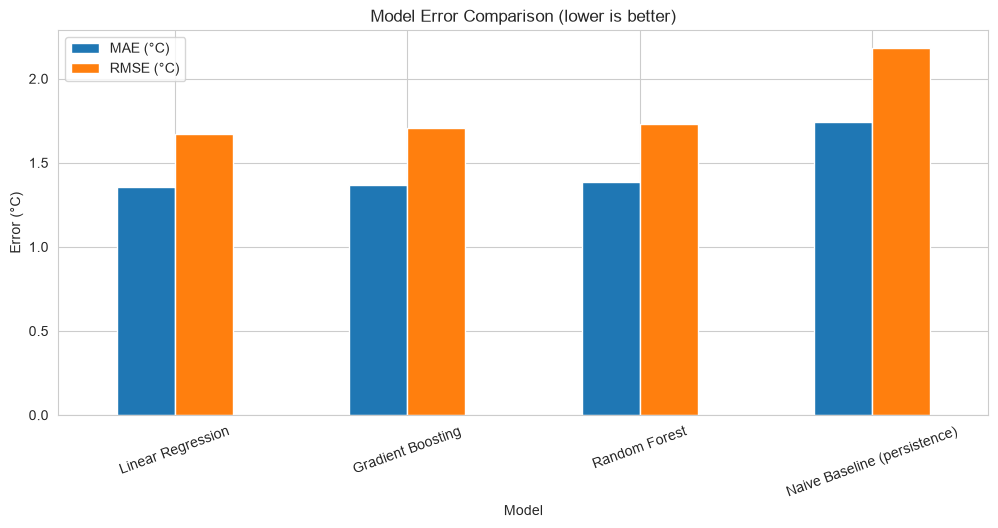

In [33]:
results_df.set_index('Model')[['MAE (°C)', 'RMSE (°C)']].plot(kind='bar')
plt.title('Model Error Comparison (lower is better)')
plt.ylabel('Error (°C)')
plt.xticks(rotation=20)
plt.show()


Best model: Linear Regression


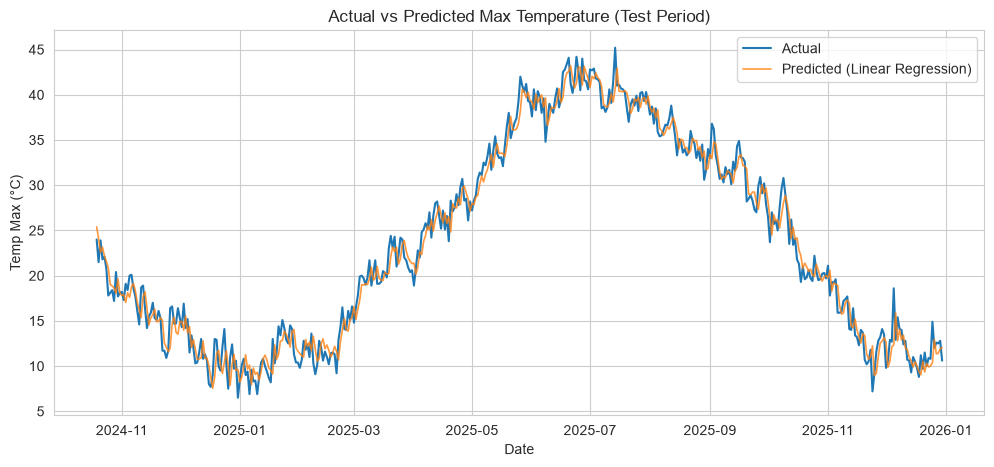

In [34]:
best_model_name = results_df.iloc[0]['Model']
print('Best model:', best_model_name)

pred_map = {
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gbr_pred,
    'Naive Baseline (persistence)': X_test['temp_max_lag1'].values,
}
best_pred = pred_map[best_model_name]

plt.plot(dates_test, y_test.values, label='Actual', linewidth=1.5)
plt.plot(dates_test, best_pred, label=f'Predicted ({best_model_name})', linewidth=1.2, alpha=0.8)
plt.title('Actual vs Predicted Max Temperature (Test Period)')
plt.xlabel('Date')
plt.ylabel('Temp Max (°C)')
plt.legend()
plt.show()


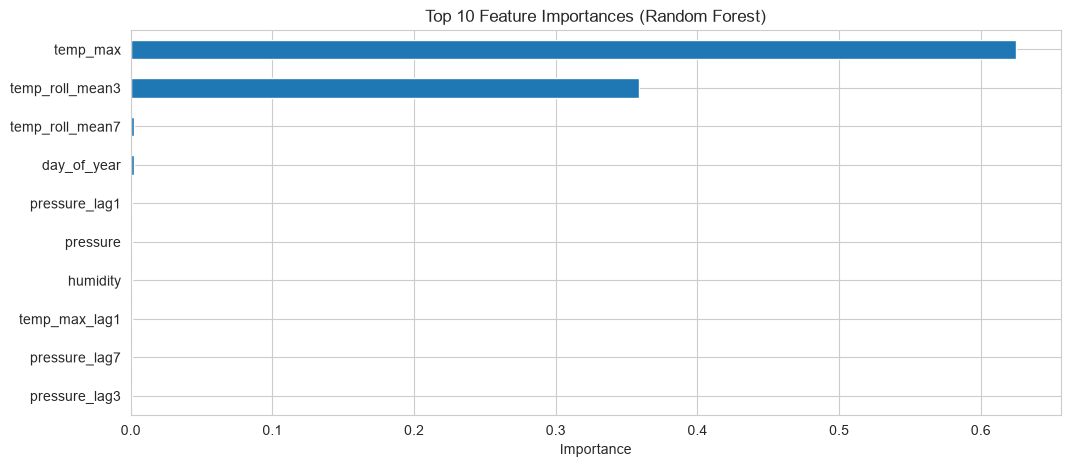

In [35]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


## 8. Rolling 7-Day Forecast

A quick demo of how you'd use the trained model operationally: predict one day ahead, feed that
prediction back in as the new "yesterday", and repeat for a week. Error compounds the further out
you go — which is exactly why real forecasts get less confident past 3-4 days.


In [36]:
def forecast_next_n_days(model, last_row, feature_cols, n_days=7):
    row = last_row.copy()
    preds = []
    for i in range(n_days):
        x = pd.DataFrame([row[feature_cols]])
        next_temp = model.predict(x)[0]
        preds.append(next_temp)

        # shift lag features forward for the next iteration
        for lag in [7, 3, 2, 1]:
            prev_col = f'temp_max_lag{lag - 1}' if lag > 1 else 'temp_max'
            if f'temp_max_lag{lag}' in row.index and prev_col in row.index:
                row[f'temp_max_lag{lag}'] = row[prev_col]
        row['temp_max'] = next_temp
    return preds

last_row = data.iloc[-1]
future_preds = forecast_next_n_days(gbr, last_row, feature_cols, n_days=7)
future_dates = pd.date_range(last_row['date'] + pd.Timedelta(days=1), periods=7)

forecast_df = pd.DataFrame({'date': future_dates, 'predicted_temp_max': np.round(future_preds, 1)})
forecast_df


,date,predicted_temp_max
0,2025-12-31,12.0
1,2026-01-01,11.9
2,2026-01-02,11.9
3,2026-01-03,11.9
4,2026-01-04,11.9
5,2026-01-05,11.9
6,2026-01-06,11.9


## 9. Conclusion

- All three models beat the naive persistence baseline (RMSE 2.18 °C). Linear Regression performed best (MAE 1.36 °C, RMSE 1.67 °C, R2 0.976), followed closely by Gradient Boosting and Random Forest. The gap between the three models is small, which shows that the engineered lag and rolling features, not the choice of algorithm, drive most of the accuracy.
- The most important features were today's max temperature and the 3-day rolling mean. Seasonal features like day-of-year added little, because the lag features already carry the seasonal signal.
- Note: the data used here is synthetically generated, so these scores show that the pipeline works, not real-world forecasting accuracy.

**Next steps for a production version:**
1. Swap in real station data (NOAA/IMD/OpenWeatherMap history) via the loader cell in Section 2.
2. Add exogenous NWP model output (e.g., GFS temperature) as a feature.
3. Try a dedicated time-series model (SARIMA, Prophet, or an LSTM) and compare against this approach.
4. Retrain on a rolling window and monitor drift, since climate patterns shift year to year.